# Очистка и структурирование данных

Второй шаг проекта: приводим сырые данные, собранные в ноутбуке **[1.parsing](1.parsing.ipynb)**, в пригодный для анализа вид.

**Что делаем:** объединяем 65 отдельных CSV-файлов (по одному на пару банк-продукт) в единый датасет, очищаем тексты отзывов от HTML-тегов, разбираемся с пропусками, проверяем на дубликаты и пересечения отзывов между продуктовыми категориями, оцениваем подозрительную активность отдельных пользователей.  

**Результат ноутбука:** два CSV-файла - `reviews_clean.csv` (полная таблица, одна строка = одна пара отзыв-продукт, для продуктового анализа) и `reviews_by_bank.csv` (дедуплицированная по отзывам таблица для анализа на уровне банка). Следующий этап проекта в ноутбуке **[3.EDA](3.EDA.ipynb)**.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
BANKS = ["sovcombank", "alfabank", "tcs", "vtb", "sberbank"]
PRODUCTS = ["hypothec", "autocredits", "credits", "restructing", "deposits", "transfers", "currency_exchange",
            "remote", "other", "mobile_app", "individual", "creditcards", "debitcards"]

## Соберем все в одну таблицу
Сейчас данные лежат в 65 таблицах. Одна таблица соответствует паре (bank, product)  
**Задача**: объединить все данные в одну таблицу. Для этого в каждой таблице добавим столбцы ```bank``` и ```product```, а потом объединим таблицы ```concat'ом```

In [3]:
all_dfs = []

for bank in BANKS:
    for product in PRODUCTS:
        df = pd.read_csv(f"{bank}_{product}.csv")
        df["bank"] = bank
        df["product"] = product
        all_dfs.append(df)

all_dfs = [df for df in all_dfs if not df.empty]
reviews = pd.concat(all_dfs, ignore_index=True)
reviews.to_csv("reviews.csv", index=False)

## Посмотрим, с чем мы вообще имеем дело

### 1. Первичный осмотр

In [2]:
reviews = pd.read_csv("reviews.csv")

In [6]:
print(f"Размер датасета: {reviews.shape}")

Размер датасета: (175315, 10)


In [9]:
print("Столбцы датасета:")
print(*reviews.columns.to_list(), sep="\n")

Столбцы датасета:
id
title
userName
text
grade
commentCount
dateCreate
resolutionIsApproved
bank
product


In [8]:
print('Типы данных:')
print(reviews.dtypes)

Типы данных:
id                        int64
title                    object
userName                 object
text                     object
grade                   float64
commentCount              int64
dateCreate               object
resolutionIsApproved     object
bank                     object
product                  object
dtype: object


* dateCreate нужно будет приводить к datetime
* resolutionIsApproved нужно будет приводить к bool. Но здесь важно понимать, что будет значить пустая ячейка - решать нечего или вопрос пока не решен?
* grade по идее должен быть int (так как оценка от 1 до 5), но тип данных float. Скорее всего в столбце есть NaN (проверим это далее)
* bank и product можно сделать категориальным типом данных

In [10]:
reviews.head()

,id,title,userName,text,grade,commentCount,dateCreate,resolutionIsApproved,bank,product
0,13298418,Решение вопроса по действующей ипотеке,user-350426094886,<p>У меня не списывались в срок деньги по ипот...,5.0,0,2026-08-14 10:09:01,NaN,sovcombank,hypothec
1,13294217,Страхование ипотеки,user-391523901770,<p>12.08.2026 г. в 09:49 я обратилась в чат ба...,5.0,1,2026-08-12 10:22:35,NaN,sovcombank,hypothec
2,13292045,Повышение ставки по ипотеке,Mr.electrogreen,<p>Здравствуйте! \r\n\r\nПрошу решить проблему...,1.0,2,2026-08-11 12:08:23,NaN,sovcombank,hypothec
3,13291806,Благодарность оператору Полине,NtWqA9ba,<ol>\r\n<li>Уже который раз оператор Полина по...,5.0,3,2026-08-11 10:50:23,NaN,sovcombank,hypothec
4,13289548,Консультация специалиста,user-770826034738,"<p>Сегодня, 10 августа 2026г, в 9:44 по Мск я ...",5.0,1,2026-08-10 10:24:12,NaN,sovcombank,hypothec


### 2. Очистка текстов отзывов от лишних символов

In [11]:
import re

#### 2.a Проверим, есть ли вообще проблема
Проверка на остатки HTML-тегов вида \<p>, \<br>, \</div>

In [12]:
html_pattern = re.compile(r"<[a-zA-Z/][^>]*>")
has_html = reviews["text"].fillna("").astype(str).str.contains(html_pattern)
print(f"Строк с HTML-тегами в тексте: {has_html.sum()}")

Строк с HTML-тегами в тексте: 165549


Ищем нераскодированые unicode escape-последовательности вида \u003C

In [13]:
unicode_escape_pattern = re.compile(r"\\u[0-9a-fA-F]{4}")
has_escapes = reviews["text"].fillna("").astype(str).str.contains(unicode_escape_pattern)
print(f"Строк с escape-последовательностями: {has_escapes.sum()}")

Строк с escape-последовательностями: 0


Проверим, есть ли лишние пробелы/переносы строк

In [14]:
has_multiple_spaces = reviews["text"].fillna("").astype(str).str.contains(r"\s{2,}")
print(f"Строк с двойными+ пробелами/переносами: {has_multiple_spaces.sum()}")

Строк с двойными+ пробелами/переносами: 122497


Значит, нужно почистить тексты от оставшихся html-тегов и лишних пробельных символов
#### 2.b Очистка текстов

In [15]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(html_pattern, " ", text)  # убираем html-теги, заменяя на пробел
    text = re.sub(r"\s+", " ", text)  # схлопываем множественные пробельные символы
    text = text.strip()
    return text
 
reviews["text"] = reviews["text"].apply(clean_text)
reviews["title"] = reviews["title"].apply(clean_text)

In [17]:
reviews[["title", "text"]].head()

,title,text
0,Решение вопроса по действующей ипотеке,У меня не списывались в срок деньги по ипотеке...
1,Страхование ипотеки,12.08.2026 г. в 09:49 я обратилась в чат банка...
2,Повышение ставки по ипотеке,Здравствуйте! Прошу решить проблему по повышен...
3,Благодарность оператору Полине,Уже который раз оператор Полина помогает решит...
4,Консультация специалиста,"Сегодня, 10 августа 2026г, в 9:44 по Мск я обр..."


### 3. Пропуски в данных

In [18]:
reviews.isna().sum() 

id                           0
title                        0
userName                     0
text                         0
grade                        8
commentCount                 0
dateCreate                   0
resolutionIsApproved    166889
bank                         0
product                      0
dtype: int64

#### 3.a Пропуски в grade

Есть пропуски в grade, как и предполагалось. Хочу посмотреть, насколько содержательные текста этих отзывов без оценки.

In [ ]:
missing_grade = reviews[reviews["grade"].isna()]

for _, row in missing_grade.iterrows():
    print(f"id: {row['id']}")
    print(f"grade: {row['grade']}")
    print(f"bank: {row['bank']}, product: {row['product']}")
    print(f"dateCreate: {row['dateCreate']}")
    print(f"title: {row['title']}")
    print(f"text: {row['text']}")
    print()

Текст у каждого отзыва содержательный, поэтому не будем выбрасывать эти строки целиком: они могут пригодится для текстового анализа. Просто будем исключать их фильтром там, где будем считать метрики по grade

#### 3.b Пропуски в resolutionIsApproved
Вот тут мы уже видим 166889/175315 (~95%) пропусков. Но это еще не значит, что проблема в качестве данных.  
Поле имеет смысл только для отзывов определённого типа - жалоб/проблемных обращений, где вообще имеет смысл говорить о "решении". Для обычного отзыва ("взял вклад, всё ок") такое поле просто не имеет смысл.  

Прежде чем решать, что с этими пропусками делать, стоит проверить:
* Распределение grade у строк с заполненным resolutionIsApproved и с пропуском. Если у "заполненных" оценки в среднем ниже, это подтверждает, что поле относится к жалобам

In [20]:
reviews.loc[reviews['resolutionIsApproved'].notna(), 'grade'].describe()

count    8426.000000
mean        1.221576
std         0.550297
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         5.000000
Name: grade, dtype: float64

In [21]:
reviews.loc[reviews['resolutionIsApproved'].isna(), 'grade'].describe()

count    166881.000000
mean          4.683535
std           1.029511
min           1.000000
25%           5.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: grade, dtype: float64

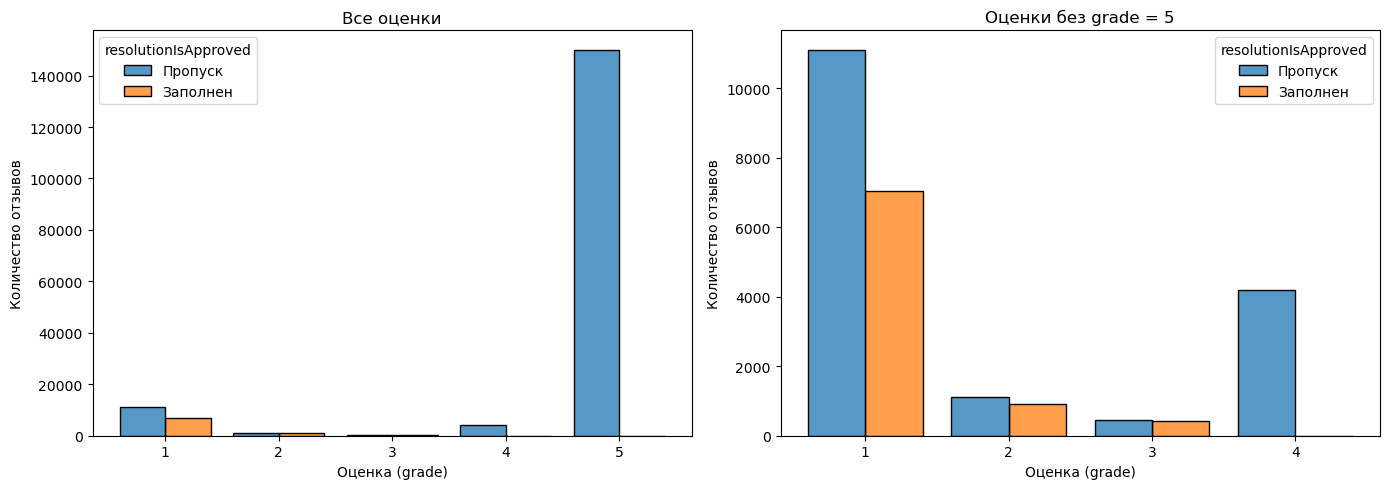

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Первый график (все данные) на левой половине (ax=ax1)
sns.histplot(
    data=reviews,
    x="grade",
    hue=reviews["resolutionIsApproved"].isna().map({True: "Пропуск", False: "Заполнен"}),
    discrete=True,
    multiple="dodge",
    shrink=0.8,
    ax=ax1
)
ax1.set_title("Все оценки")
ax1.set_xlabel("Оценка (grade)")
ax1.set_ylabel("Количество отзывов")
ax1.set_xticks([1, 2, 3, 4, 5])

# 2. Второй график (без 5) на правой половине (ax=ax2)
filtered_reviews = reviews[reviews["grade"] < 5]
sns.histplot(
    data=filtered_reviews,
    x="grade",
    hue=filtered_reviews["resolutionIsApproved"].isna().map({True: "Пропуск", False: "Заполнен"}),
    discrete=True,
    multiple="dodge",
    shrink=0.8,
    ax=ax2
)
ax2.set_title("Оценки без grade = 5")
ax2.set_xlabel("Оценка (grade)")
ax2.set_ylabel("Количество отзывов")
ax2.set_xticks([1, 2, 3, 4]) 

plt.tight_layout()
plt.show()

Как видим, гипотеза подтвердилась: поле заполняется почти исключительно у негативных отзывов. Получается, что пропуски в колонке не случайны, ячейки в ней заполняются только для отзывов, поданных как жалобы на проблему. Соответственно, импутация пропусков (например, заполнение False) исказила бы смысл поля - большинство пропусков не означают "жалоба не решена", а означают "отзыв не является жалобой". Поэтому колонку оставим без изменений, а анализ по ней будем проводить только на подмножестве строк с непустым значением.

#### 3.c Тексты отзывов
Пропусков в текстах отзывов хоть и нет, но нужно посмотреть вообще, какой длины отзывы. Есть ли среди них неинформативные отзывы, в которых всего пара слов

In [25]:
reviews["text_len"] = reviews["text"].fillna("").astype(str).str.len()
print(reviews["text_len"].describe())
 
very_short = (reviews["text_len"] < 20).sum()
print(f"\nОтзывов короче 20 символов: {very_short} ({very_short/len(df):.2%})")

count    175315.000000
mean        684.616456
std         535.945470
min          57.000000
25%         351.000000
50%         487.000000
75%         789.000000
max        3827.000000
Name: text_len, dtype: float64

Отзывов короче 20 символов: 0 (0.00%)


Результат приятный: минимальная длина - 57 символов, отзывов короче 20 символов нет вообще. То есть проблемы однословных отзывов нет  
Колонку text_len оставим, может пригодится позже как фича

### 4. Дубли
#### 4.a Поиск полных дублей
Проверим, есть ли в датасете полные дубли. Они могли появится при парсинге, отзывы могли задвоиться

In [26]:
print(reviews.duplicated().sum())

0


Ура! Полных дублей нет, это хорошо

#### 4.b Пересечения между категориями
Отсутствие полных дублей - это хорошо, но может быть такое, что один отзыв попал в несколько категорий одного банка. На этом этапе как раз и проверим, есть ли такие ситуации в датасете

In [27]:
print(f"Количество уникальных отзывов: {reviews['id'].nunique()}")
print(f"Всего отзывов: {len(reviews)}")

Количество уникальных отзывов: 144100
Всего отзывов: 175315


Давайте сначала проверим, есть ли пересечения по отзывам среди банков. Нужно исключить маловероятный (но все же вероятный) вариант, когда один отзыв попадает в несколько банков. Кстати, еще такое может быть, если пространство id отзывов у каждого банка\категории свое

In [28]:
id_sets = {}
for bank in BANKS:
    id_sets[bank] = set(reviews.loc[reviews["bank"]==bank, "id"])

for i in range(len(BANKS)):
        for j in range(i + 1, len(BANKS)):
            b1, b2 = BANKS[i], BANKS[j]
            overlap = id_sets[b1] & id_sets[b2]
            print(f"{b1} и {b2} пересекаются по {len(overlap)} id")

sovcombank и alfabank пересекаются по 0 id
sovcombank и tcs пересекаются по 0 id
sovcombank и vtb пересекаются по 0 id
sovcombank и sberbank пересекаются по 0 id
alfabank и tcs пересекаются по 0 id
alfabank и vtb пересекаются по 0 id
alfabank и sberbank пересекаются по 0 id
tcs и vtb пересекаются по 0 id
tcs и sberbank пересекаются по 0 id
vtb и sberbank пересекаются по 0 id


Данный результат говорит нам о том, что отзывы не пересекаются по банкам. Пересечения происходят внутри банков по категориям. Что и предполагали: один отзыв может попасть в несколько категорий внутри банка.  
Посмотрим на эти пересечения

In [ ]:
for bank in BANKS:
    print(f"Проверка банка {bank}")
    id_sets = {}
    for product in PRODUCTS:
        id_sets[product] = set(reviews.loc[(reviews["bank"]==bank) & (reviews["product"]==product), "id"])

    #id_sets = {'creditcards': (...), 'deposits': (...), ...}
 
    for i in range(len(PRODUCTS)):
        for j in range(i + 1, len(PRODUCTS)):
            p1, p2 = PRODUCTS[i], PRODUCTS[j]
            overlap = id_sets[p1] & id_sets[p2]
            if len(overlap) != 0:
                print(f"{bank}: {p1} и {p2} пересекаются по {len(overlap)} id")

Пересечения есть и их не мало  
Вот столько дублей по каждому банку:

In [30]:
reviews.groupby('bank')['id'].apply(lambda x: x.duplicated().sum())

bank
alfabank      14465
sberbank        799
sovcombank    10500
tcs            3921
vtb            1530
Name: id, dtype: int64

А вдруг в каждой категории свое пространство id отзывов?

In [31]:
sub = reviews.groupby(['bank', 'id']).nunique()[['grade', 'text', 'dateCreate']]
sub = sub[(sub['grade'] > 1) | (sub['text'] > 1) | (sub['dateCreate'] > 1)]
print(len(sub))

0


Ответ: нет. Все дубли по id различаются только по колонке product

Решим данную проблему путем создания второй таблицы. То есть будет два разных представления данных:
1. **reviews.csv** (как сейчас, одна строка = одна пара отзыв-продукт). Эту таблицу будем использовать для анализа по продуктам. Тут дубли по id - не баг: один отзыв законно относится к нескольким продуктам, и для продуктовой разбивки это корректно.
2. **reviews_by_bank.csv** - cхлопнутый "по банкам" (bank, id + остальные поля один раз + список продуктов). Эта таблица нужна будет там, где будем считать общие метрики по банку. Если не схлопнуть, некоторые отзывы задвоятся/утроятся и т.п. в подсчёте.

In [34]:
reviews_by_bank = (
    reviews.groupby(['bank', 'id'])
    .agg({
        'title': 'first',
        'userName': 'first',
        'text': 'first',
        'grade': 'first',
        'commentCount': 'first',
        'dateCreate': 'first',
        'resolutionIsApproved': 'first',
        'text_len': 'first',
        'product': lambda x: list(x)
    })
    .reset_index()
)
reviews_by_bank.head()
reviews_by_bank.to_csv("reviews_by_bank.csv", index=False)

### 5. Еще пара проверок
#### 5.a Проверка на подозрительную активность
Посмотрим, были ли пользователи, которые оставляли несколько отзывов и посчитаем по ним статистику

In [35]:
user_activity = reviews_by_bank.groupby('userName').size().sort_values(ascending=False)
user_activity.head(20)

userName
user-805517481203    121
bambinito             85
user_1024             85
user_1194688          74
user-157717137558     67
user-243818162361     67
vint2007              64
user-649718241491     64
user-863513988499     63
user-810718283025     63
user-255916823819     62
usanoval              62
user-850022873741     61
user-617513997278     60
user-951917374961     60
jet1986               59
user-845113699887     59
user-737617115073     58
user-709010056488     58
user-156122490240     57
dtype: int64

In [38]:
top_users = user_activity.head(10).index.tolist()

for user in top_users:
    user_reviews = reviews_by_bank[reviews_by_bank['userName'] == user]
    
    print(f"===== {user} ({len(user_reviews)} отзывов) =====")
    
    # Разнообразие банков и продуктов
    print(f"Банков: {user_reviews['bank'].nunique()} — {user_reviews['bank'].value_counts().to_dict()}")
    all_products = [p for plist in user_reviews['product'] for p in plist]
    print(f"Уникальных продуктов: {len(set(all_products))}")

    # Разброс оценок
    print(f"Оценки: {user_reviews['grade'].value_counts().sort_index().to_dict()}")
    print(f"Grade std: {user_reviews['grade'].std():.2f}")
    
    # Похожесть текстов (длина)
    print(f"Длина текста: mean={user_reviews['text_len'].mean():.0f}, "
          f"std={user_reviews['text_len'].std():.0f}, "
          f"min={user_reviews['text_len'].min()}, max={user_reviews['text_len'].max()}")
    
    # Распределение по датам
    dates = pd.to_datetime(user_reviews['dateCreate']).sort_values()
    date_span_days = (dates.max() - dates.min()).days
    print(f"Диапазон дат: {dates.min().date()} — {dates.max().date()} ({date_span_days} дней)")

    # если много отзывов за короткий период - подозрительно
    reviews_per_day = len(user_reviews) / max(date_span_days, 1)
    print(f"Отзывов в день (в среднем по диапазону): {reviews_per_day:.2f}")
    
    print()
    

===== user-805517481203 (121 отзывов) =====
Банков: 3 — {'sovcombank': 88, 'alfabank': 21, 'tcs': 12}
Уникальных продуктов: 8
Оценки: {1.0: 67, 5.0: 54}
Grade std: 2.00
Длина текста: mean=468, std=110, min=296, max=824
Диапазон дат: 2025-08-02 — 2026-06-03 (305 дней)
Отзывов в день (в среднем по диапазону): 0.40

===== bambinito (85 отзывов) =====
Банков: 5 — {'sovcombank': 31, 'alfabank': 27, 'tcs': 15, 'sberbank': 7, 'vtb': 5}
Уникальных продуктов: 7
Оценки: {1.0: 25, 5.0: 60}
Grade std: 1.83
Длина текста: mean=1306, std=811, min=435, max=3599
Диапазон дат: 2025-08-02 — 2026-08-04 (367 дней)
Отзывов в день (в среднем по диапазону): 0.23

===== user_1024 (85 отзывов) =====
Банков: 4 — {'alfabank': 31, 'sovcombank': 30, 'tcs': 23, 'vtb': 1}
Уникальных продуктов: 8
Оценки: {1.0: 14, 2.0: 7, 3.0: 3, 4.0: 17, 5.0: 44}
Grade std: 1.54
Длина текста: mean=596, std=314, min=302, max=2298
Диапазон дат: 2025-08-07 — 2026-08-15 (373 дней)
Отзывов в день (в среднем по диапазону): 0.23

===== user

У большинства активных пользователей оценки смешанные и правдоподобные, кроме vint2007 и user-863513988499 - все отзывы имеют grade=5, что нетипично для органичного поведения.  
Решено не исключать эти записи из датасета, так как на объёме 175К+ отзывов её влияние на общие выводы незначительно

#### 5.b Проверка диапозона дат

In [45]:
dates = pd.to_datetime(reviews['dateCreate'])
print(f"Охвачен период с {dates.min()} по {dates.max()}")

Охвачен период с 2025-08-01 00:02:11 по 2026-08-28 10:05:41


#### 5.с Проверка дыр в датах по неделям

In [46]:
dates = dates.to_frame()
weekly_counts = dates.set_index("dateCreate").resample("W").size()
empty_weeks = (weekly_counts == 0).sum()
print(f"Всего недель в периоде: {len(weekly_counts)}, из них пустых (0 отзывов): {empty_weeks}")

Всего недель в периоде: 57, из них пустых (0 отзывов): 0


### 6. Составим сводную таблицу

In [48]:
summary = pd.DataFrame(index=BANKS, columns=PRODUCTS)
for bank in BANKS:
    for product in PRODUCTS:
        summary.loc[bank, product] = len(reviews[(reviews["bank"] == bank) & (reviews["product"] == product)])
 
summary["ИТОГО"] = summary.sum(axis=1)
summary.loc["ИТОГО"] = summary.sum(axis=0)
 
summary

,hypothec,autocredits,credits,restructing,deposits,transfers,currency_exchange,remote,other,mobile_app,individual,creditcards,debitcards,ИТОГО
sovcombank,335,1872,3131,1039,3950,1694,12,11629,2130,876,3,11909,14560,53140
alfabank,200,45,777,129,2438,3542,34,17850,2797,2402,14,8900,51377,90505
tcs,185,418,364,168,639,887,26,4797,1000,524,0,2793,7487,19288
vtb,318,104,418,93,593,584,11,1205,416,257,0,661,2903,7563
sberbank,1656,75,227,87,177,359,6,577,280,42,0,408,925,4819
ИТОГО,2694,2514,4917,1516,7797,7066,89,36058,6623,4101,17,24671,77252,175315


In [49]:
reviews.to_csv("reviews_clean.csv", index=False)